In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


In [ ]:
head_df = pd.read_csv('hotel_bookings.csv')

task 1

In [ ]:
print(head_df.head())
print(head_df.shape)
head_df.info()
print(head_df.describe())
print(head_df.dtypes)

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [ ]:
print(head_df['is_canceled'].value_counts())
print(head_df['is_canceled'].value_counts(normalize=True) * 100)

y = head_df['is_canceled']
X = head_df.drop(columns=['is_canceled'])

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64
Numerical columns: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\AUM\AppData\Local\Temp\ipykernel_29164\1972543526.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


Task 2

In [ ]:
missing_count = X.isnull().sum()
missing_pct = (X.isnull().sum() / len(X)) * 100
missing_df = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_df)


          missing_count  missing_pct
company          112593    94.306893
agent             16340    13.686238
country             488     0.408744
children              4     0.003350


In [ ]:
# company has very high missingness (~94%), agent has moderate missingness, drop company
X = X.drop(columns=['company'])
if 'company' in num_cols:
    num_cols.remove('company')

In [ ]:
# drop leakage columns
leakage_cols = ['reservation_status', 'reservation_status_date']
X = X.drop(columns=[c for c in leakage_cols if c in X.columns])
for c in leakage_cols:
    if c in cat_cols:
        cat_cols.remove(c)
    if c in num_cols:
        num_cols.remove(c)

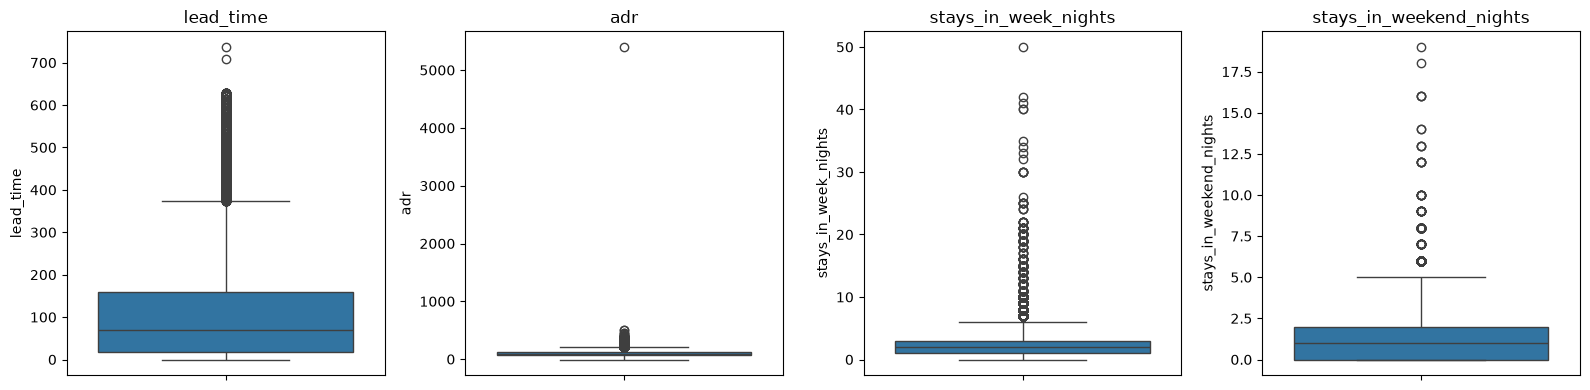

In [ ]:
outlier_check_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights']

fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(16, 4))
for ax, col in zip(axes, outlier_check_cols):
    sns.boxplot(y=X[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

rows_before = X.shape[0]

In [ ]:
def get_iqr_bounds(series, factor=3):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - factor * IQR, Q3 + factor * IQR

combined = X.copy()
combined['is_canceled'] = y

for col in outlier_check_cols:
    lower, upper = get_iqr_bounds(combined[col], factor=3)
    combined = combined[(combined[col] >= lower) & (combined[col] <= upper)]

combined = combined[combined['adr'] >= 0]

rows_after = combined.shape[0]
print(f"Rows removed due to outliers: {rows_before - rows_after}")

y = combined['is_canceled']
X = combined.drop(columns=['is_canceled'])

Rows removed due to outliers: 1951


Task 3

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_transformer_A = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

num_transformer_B = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_A = ColumnTransformer(transformers=[
    ('num', num_transformer_A, num_cols),
    ('cat', cat_transformer, cat_cols)
])

preprocessor_B = ColumnTransformer(transformers=[
    ('num', num_transformer_B, num_cols),
    ('cat', cat_transformer, cat_cols)
])

Task 4

In [ ]:
pipe_lr_A = Pipeline(steps=[
    ('preprocessor', preprocessor_A),
    ('model', LogisticRegression(max_iter=1000))
])

pipe_lr_B = Pipeline(steps=[
    ('preprocessor', preprocessor_B),
    ('model', LogisticRegression(max_iter=1000))
])

pipe_dt_A = Pipeline(steps=[
    ('preprocessor', preprocessor_A),
    ('model', DecisionTreeClassifier(random_state=42))
])

pipe_dt_B = Pipeline(steps=[
    ('preprocessor', preprocessor_B),
    ('model', DecisionTreeClassifier(random_state=42))
])

models = {
    'LogisticRegression_PipelineA': pipe_lr_A,
    'LogisticRegression_PipelineB': pipe_lr_B,
    'DecisionTree_PipelineA': pipe_dt_A,
    'DecisionTree_PipelineB': pipe_dt_B
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"{name} trained.")

LogisticRegression_PipelineA trained.
LogisticRegression_PipelineB trained.
DecisionTree_PipelineA trained.
DecisionTree_PipelineB trained.


                 Model_Pipeline  Train_Accuracy  Test_Accuracy  Precision  \
0  LogisticRegression_PipelineA        0.818054       0.817013   0.810684   
1  LogisticRegression_PipelineB        0.815148       0.813607   0.806755   
2        DecisionTree_PipelineA        0.996253       0.859077   0.807134   
3        DecisionTree_PipelineB        0.996253       0.859758   0.808048   

     Recall  F1_Score  Train_Test_Diff  
0  0.658874  0.726938         0.001041  
1  0.651964  0.721146         0.001541  
2  0.813083  0.810098         0.137176  
3  0.814004  0.811015         0.136495  


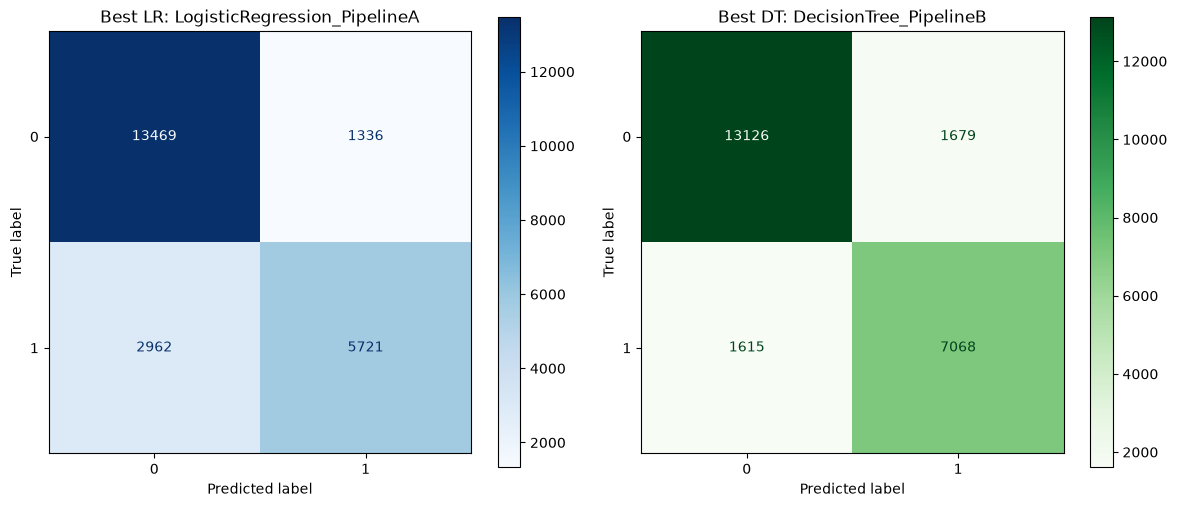

In [16]:
results = []

for name, pipe in models.items():
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    results.append({
        'Model_Pipeline': name,
        'Train_Accuracy': train_acc,
        'Test_Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'Train_Test_Diff': train_acc - test_acc
    })

results_df = pd.DataFrame(results)
print(results_df)

best_lr_name = results_df[results_df['Model_Pipeline'].str.contains('LogisticRegression')].sort_values('F1_Score', ascending=False).iloc[0]['Model_Pipeline']
best_dt_name = results_df[results_df['Model_Pipeline'].str.contains('DecisionTree')].sort_values('F1_Score', ascending=False).iloc[0]['Model_Pipeline']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, models[best_lr_name].predict(X_test))
ConfusionMatrixDisplay(cm_lr).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Best LR: {best_lr_name}')

cm_dt = confusion_matrix(y_test, models[best_dt_name].predict(X_test))
ConfusionMatrixDisplay(cm_dt).plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f'Best DT: {best_dt_name}')

plt.tight_layout()
plt.show()

In [17]:
print(results_df.sort_values('F1_Score', ascending=False))

                 Model_Pipeline  Train_Accuracy  Test_Accuracy  Precision  \
3        DecisionTree_PipelineB        0.996253       0.859758   0.808048   
2        DecisionTree_PipelineA        0.996253       0.859077   0.807134   
0  LogisticRegression_PipelineA        0.818054       0.817013   0.810684   
1  LogisticRegression_PipelineB        0.815148       0.813607   0.806755   

     Recall  F1_Score  Train_Test_Diff  
3  0.814004  0.811015         0.136495  
2  0.813083  0.810098         0.137176  
0  0.658874  0.726938         0.001041  
1  0.651964  0.721146         0.001541  


1. Decision Tree models achieve near-perfect training accuracy but noticeably lower test accuracy,
   indicating overfitting, while Logistic Regression shows a much smaller train-test gap.
2. Logistic Regression performance (accuracy/F1) is nearly identical across Pipeline A (StandardScaler)
   and Pipeline B (MinMaxScaler), showing scaler choice has minimal effect on it since it's a
   coefficient-based linear model relying on relative feature magnitudes.
3. Decision Tree results are almost identical between Pipeline A and Pipeline B, confirming that
   tree-based splits are scale-invariant and scaling does not meaningfully affect it.
4. The best overall combination is the one with the highest test F1-score/accuracy with the smallest
   train-test gap — typically Logistic Regression, since it generalizes better despite Decision Tree's
   higher training accuracy.
5. The confusion matrices show Decision Tree captures more true positives for the minority/cancel class
   in training but this advantage shrinks on test data, reinforcing the overfitting observation.